In [1]:
# load gaussian_annealing_naive_unweighted
import os
import pickle
import sys 

sys.path.append('.')
sys.path.append('..')
sys.path.append('../data')
# from src.plotting import create_all_plots

# print(os.listdir('../data'))

# data = pickle.load(open('polynomial/double_well/leapfrog/cd_unweighted.pkl', 'rb'))


In [2]:
# data['snapshots']['times']

[0.0, 0.3960103988647461, 0.7919977307319641, 1.0]
[0.00025 0.00025 0.00025 ... 0.00025 0.00025 0.00025] log weights
[0.00025 0.00025 0.00025 ... 0.00025 0.00025 0.00025] real weights
empirical expectation 1.0350436


/var/folders/v9/977m2z015_b794hqf_nk0q1r0000gn/T/ipykernel_21010/2633555547.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rho = rho / np.trapz(rho, x)  # Normalize


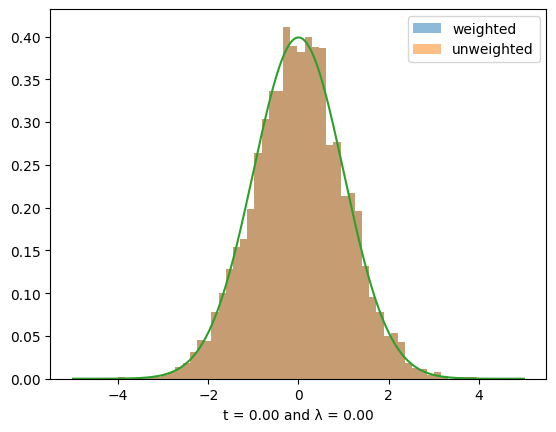

[ -7.892042   -8.46664    -8.763556  ... -10.400053   -7.7145114
 -10.270681 ] log weights
[3.7370544e-04 2.1037046e-04 1.5632779e-04 ... 3.0430869e-05 4.4630325e-04
 3.4633769e-05] real weights
empirical expectation 0.98982775


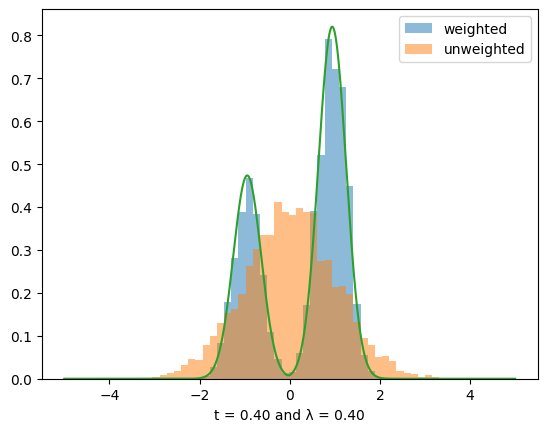

[-8.602351 -8.602542 -9.473921 ... -8.55898  -8.424632 -8.424689] log weights
[1.8367326e-04 1.8363823e-04 7.6829579e-05 ... 1.9181466e-04 2.1939584e-04
 2.1938328e-04] real weights
empirical expectation 1.0416839


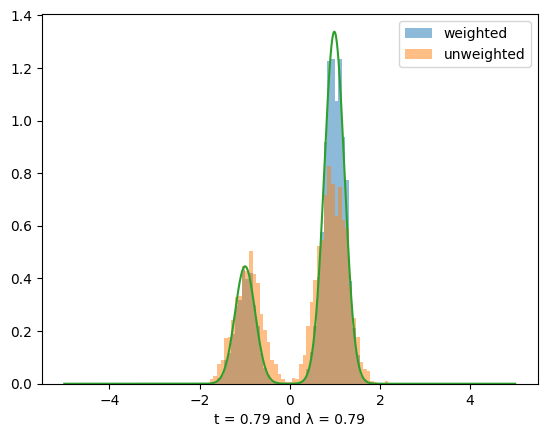

[-8.547907 -8.439715 -8.439464 ... -8.524859 -8.45434  -8.454404] log weights
[0.00019395 0.00021611 0.00021617 ... 0.00019847 0.00021297 0.00021296] real weights
empirical expectation 1.0504382


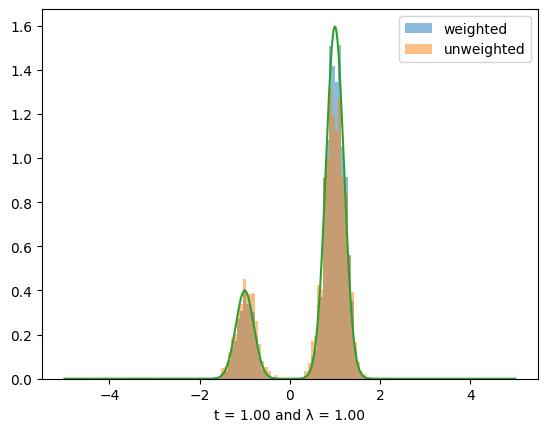

cost: 16000


<Figure size 640x480 with 0 Axes>

In [42]:
# plot a gaussian with unit variance, 1D
import numpy as np
import matplotlib.pyplot as plt
from src.systems import SYSTEMS
import jax.numpy as jnp
# y is a normal pdf (scipy) with std 0.1
from scipy.stats import norm
from src.utils import compute_ess, compute_expectation_over_equilibrium, normalize_log_weights
# y = norm.pdf(x, 0, 1/0.5)



def make_hist(file, system_name):
    data = pickle.load(open(file, 'rb'))

    x = np.linspace(-5, 5, 1000)


    times = data['snapshots']['times']
    # lambdas = times 
    N = len(times)
    M = data['snapshots']['particles'][0].shape[0]
    lambdas = data['snapshots']['lam']
    print(times)
    # esses = []
    for i in range(len(data['snapshots']['particles'])):
    # for i in range(1):
        potential = SYSTEMS[system_name]['make_V'](lambdas[i])


        y = potential(x)
        # normalize y using trapezoid integration
        rho = np.array([np.exp(-potential(point)) for point in x])
        rho = rho / np.trapz(rho, x)  # Normalize

        # print(times[i])

        particles = data['snapshots']['particles'][i]
        log_weights = data['snapshots']['weights'][i]
        print(log_weights, "log weights")
        weights = np.exp(normalize_log_weights(log_weights))
        print(weights, "real weights")
        
        all_weights = np.exp(data['snapshots']['weights'])
        all_weights = jnp.clip(all_weights, 0, 1).mean(axis=-1)


        # compute ess of weights 
        # ess = compute_ess(log_weights)
        # print(ess)
        # esses.append(ess)

        # expect = jnp.sum(weights * (particles**2)[:, 0], axis=0)
        # print(expect, "expectation", weights.shape, particles.shape, (weights * (particles**2)[:, 0]).shape)

        empirical_e = compute_expectation_over_equilibrium(particles[:, 0]**2, log_weights)
        print("empirical expectation",empirical_e)

        # all_weights = all_weights.mean(axis=-1)
        
        num_bins = 50
        plt.hist(particles[:,0], bins=num_bins, weights=weights, density=True, alpha=0.5, label='weighted')
        plt.hist(particles[:,0], bins=num_bins, density=True, alpha=0.5, label='unweighted')
        plt.plot(x, rho)
        plt.xlabel(f't = {times[i]:.2f} and λ = {lambdas[i]:.2f}')
        plt.legend()
        plt.show()
        plt.clf()


    # plt.plot(all_weights)
    # print(data)
    # plt.show()
    # plt.plot(esses)

    true_expectation = 0.1
    error = ((empirical_e - true_expectation)**2) / (2 * true_expectation)
    # print(f'error: {error} and ESS: {100/error}')
    cost_per_step = 1
    cost = cost_per_step * N * M 
    print(f'cost: {cost}')



# error_cd, estimate_cd = calculate_normalized_error(
#                     final_samples_cd, true_exp, true_var, f_func
#                 )


# system_name = 'gaussian_annealing'
system_name = 'mixture'
# system_name = 'gaussian_moving_mean'

# make_hist(file='naive/double_well/leapfrog/naive_weighted.pkl', i=0)
# make_hist(file='naive/double_well/leapfrog/naive_unweighted.pkl', i=20)
# make_hist(file='naive/double_well/leapfrog/naive_weighted.pkl', i=20)
# make_hist(file='polynomial/double_well/leapfrog/cd_unweighted.pkl', i=20)
# make_hist(file='polynomial/double_well/leapfrog/cd_weighted.pkl', i=20)

# make_hist(file=f'polynomial/{system_name}/leapfrog/cd_weighted.pkl', system_name=system_name)
make_hist(file=f'mixture_smc_adjusted_hmc.pkl', system_name=system_name)

# make_hist(file=f'naive/{system_name}/leapfrog/naive_weighted.pkl', system_name=system_name)

In [ ]:
from src.simple_benchmark import calculate_double_well_expectations

    
true_expectations = calculate_double_well_expectations(2.0)
true_expectations

{'x_squared': {'expectation': 14.6827908, 'variance': 17.694268}}

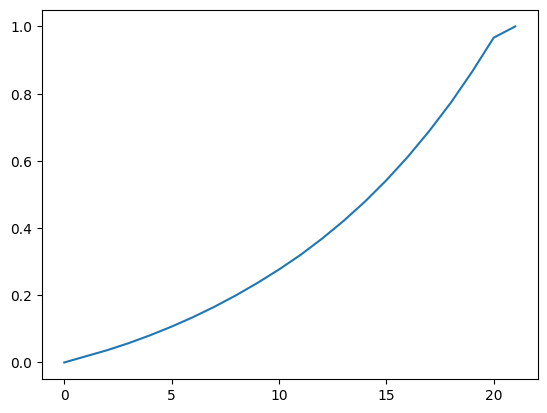

In [23]:
schedule = [0.0, 0.018310546875, 0.036585405468940735, 0.05751897394657135, 0.08098895847797394, 0.10679127275943756, 0.13503114879131317, 0.1660737246274948, 0.19997233152389526, 0.23688766360282898, 0.27675729990005493, 0.32001766562461853, 0.36832696199417114, 0.42091497778892517, 0.4785972833633423, 0.542245090007782, 0.6122046709060669, 0.6890820860862732, 0.77288419008255, 0.8658154010772705, 0.966715931892395, 1.0]

plt.plot(schedule)